#Лабораторная работа 2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
bike_data = pd.read_csv('/content/drive/MyDrive/SeoulBikeData.csv', encoding='unicode_escape')
bike_data.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


##Установка библиотек

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

##Загрузка данных с Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

bike_records = pd.read_csv('/content/drive/MyDrive/SeoulBikeData.csv', encoding='unicode_escape')

bike_records.head()
bike_records.info()
bike_records.describe()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


## Агрегация данных по дням, неделям и месяцам

<ipython-input-7-513540d61348>:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_stats = bike_records.resample('M', on='Date')['Rented Bike Count'].agg(['sum', 'mean'])


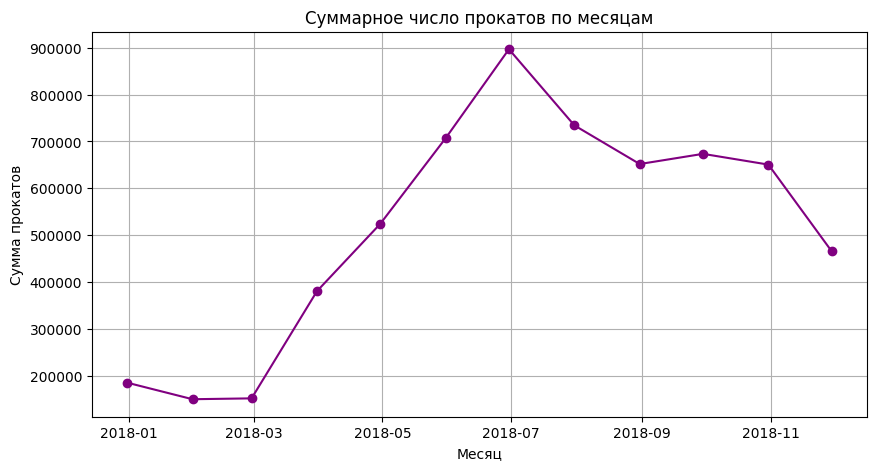

In [ ]:
bike_records['Date'] = pd.to_datetime(bike_records['Date'], format='%d/%m/%Y')

daily_stats = bike_records.groupby('Date')['Rented Bike Count'].agg(['sum', 'mean'])

weekly_stats = bike_records.resample('W', on='Date')['Rented Bike Count'].agg(['sum', 'mean'])

monthly_stats = bike_records.resample('M', on='Date')['Rented Bike Count'].agg(['sum', 'mean'])


plt.figure(figsize=(10, 5))
plt.plot(monthly_stats.index, monthly_stats['sum'], marker='o', linestyle='-', color='purple')
plt.title('Суммарное число прокатов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Сумма прокатов')
plt.grid(True)
plt.show()

## Сезонные закономерности: будни vs выходные

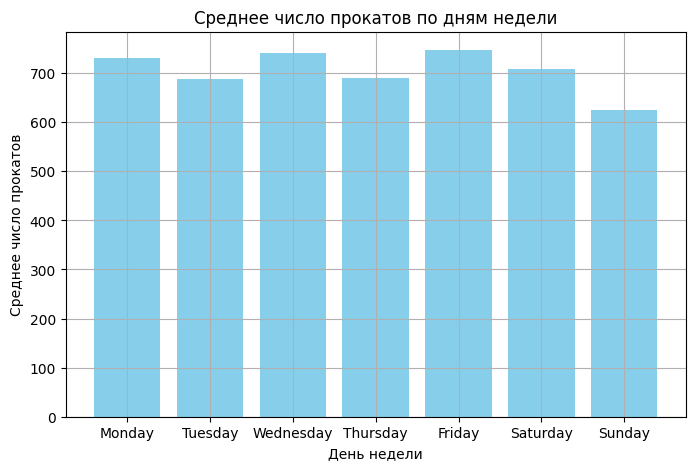

In [ ]:
bike_records['WeekDay'] = bike_records['Date'].dt.day_name()
daily_avg = bike_records.groupby('WeekDay')['Rented Bike Count'].mean()


week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


plt.figure(figsize=(8, 5))
plt.bar(week_order, daily_avg[week_order], color='skyblue')
plt.title('Среднее число прокатов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Среднее число прокатов')
plt.grid(True)
plt.show()

Среднее число прокатов в будни: 719.45
Среднее число прокатов в выходные: 667.34


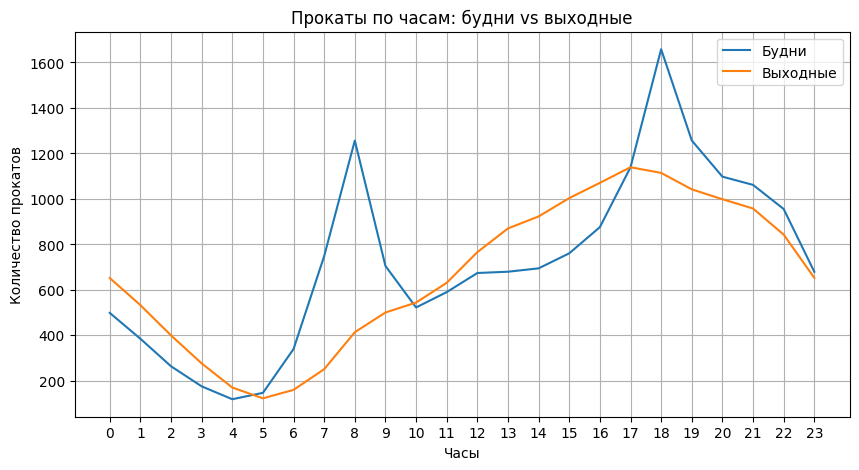

In [ ]:
bike_records['WeekendFlag'] = bike_records['WeekDay'].isin(['Saturday', 'Sunday'])


weekday_avg = bike_records[bike_records['WeekendFlag'] == False]['Rented Bike Count'].mean()
weekend_avg = bike_records[bike_records['WeekendFlag'] == True]['Rented Bike Count'].mean()

print(f"Среднее число прокатов в будни: {weekday_avg:.2f}")
print(f"Среднее число прокатов в выходные: {weekend_avg:.2f}")

plt.figure(figsize=(10, 5))
sns.lineplot(data=bike_records, x='Hour', y='Rented Bike Count', hue='WeekendFlag', errorbar=None)
plt.title('Прокаты по часам: будни vs выходные')
plt.xlabel('Часы')
plt.ylabel('Количество прокатов')
plt.legend(['Будни', 'Выходные'])
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

#### Выявление аномалий с помощью IQR

Аномалии в месяце 5:
[Timestamp('2018-05-10 00:00:00'), Timestamp('2018-05-12 00:00:00')]
--------------------------------------------------
Аномалии в месяце 6:
[Timestamp('2018-06-26 00:00:00')]
--------------------------------------------------
Аномалии в месяце 7:
[Timestamp('2018-07-01 00:00:00'), Timestamp('2018-07-02 00:00:00'), Timestamp('2018-07-09 00:00:00')]
--------------------------------------------------
Аномалии в месяце 10:
[Timestamp('2018-10-02 00:00:00'), Timestamp('2018-10-04 00:00:00'), Timestamp('2018-10-05 00:00:00'), Timestamp('2018-10-09 00:00:00')]
--------------------------------------------------
Аномалии в месяце 11:
[Timestamp('2018-11-03 00:00:00'), Timestamp('2018-11-06 00:00:00'), Timestamp('2018-11-08 00:00:00'), Timestamp('2018-11-09 00:00:00')]
--------------------------------------------------


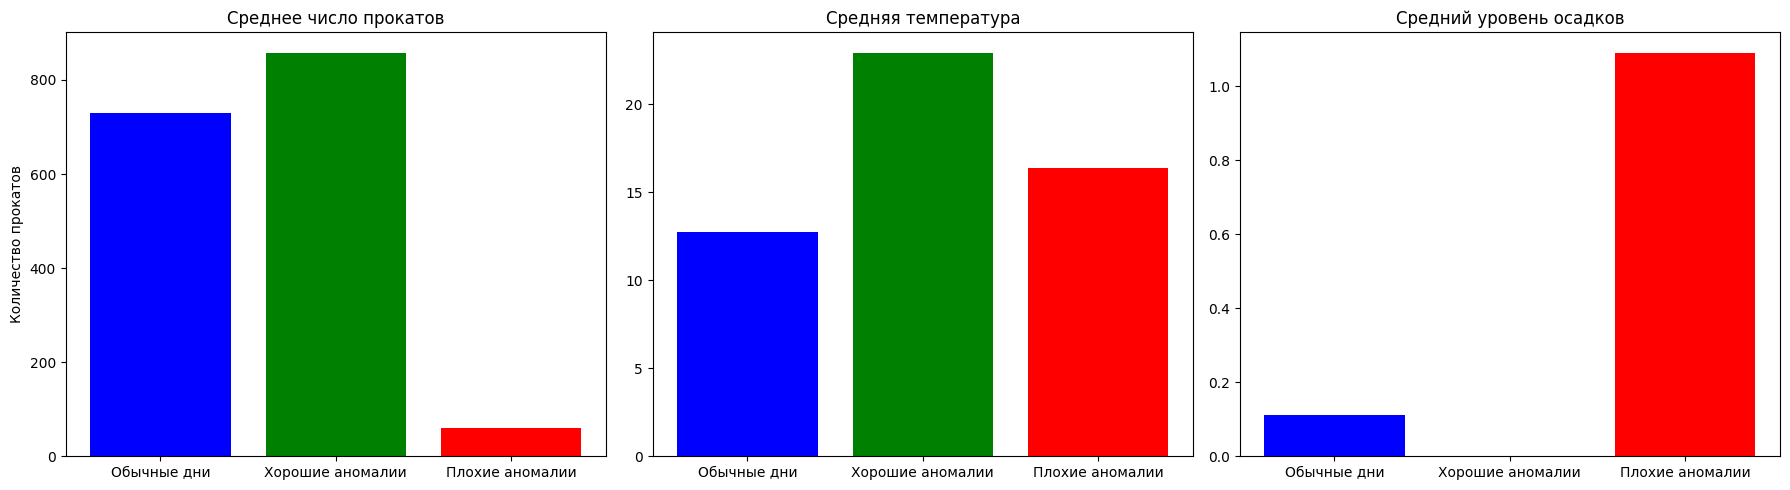

In [ ]:
daily_totals = bike_records.groupby('Date')['Rented Bike Count'].sum()
daily_totals = daily_totals.to_frame()
daily_totals['MonthNum'] = daily_totals.index.month

def detect_outliers(stats):
    q1 = stats.quantile(0.25)
    q3 = stats.quantile(0.75)
    iqr = q3 - q1
    return stats[(stats < q1 - 1.5 * iqr) | (stats > q3 + 1.5 * iqr)]

anomalies_by_month = {}
for month_num in range(1, 13):
    month_subset = daily_totals[daily_totals['MonthNum'] == month_num]['Rented Bike Count']
    anomalies = detect_outliers(month_subset)
    anomalies_by_month[month_num] = anomalies
    if not anomalies.empty:
        print(f'Аномалии в месяце {month_num}:')
        print(anomalies.index.tolist())
        print('-' * 50)

anomaly_dates = [
    '2018-05-10', '2018-05-12', '2018-06-26', '2018-07-01',
    '2018-07-02', '2018-07-09', '2018-10-02', '2018-10-04',
    '2018-10-05', '2018-10-09', '2018-11-03', '2018-11-06',
    '2018-11-08', '2018-11-09'
]
anomaly_dates = pd.to_datetime(anomaly_dates)

normal_avg = bike_records[~bike_records['Date'].isin(anomaly_dates)]['Rented Bike Count'].mean()

anomaly_subset = bike_records[bike_records['Date'].isin(anomaly_dates)]
good_anomalies = anomaly_subset[anomaly_subset['Rented Bike Count'] > normal_avg]
bad_anomalies = anomaly_subset[anomaly_subset['Rented Bike Count'] <= normal_avg]

comparison_table = pd.DataFrame({
    "Category": ["Обычные дни", "Хорошие аномалии", "Плохие аномалии"],
    "Avg_Rentals": [
        bike_records[~bike_records['Date'].isin(anomaly_dates)]['Rented Bike Count'].mean(),
        good_anomalies['Rented Bike Count'].mean(),
        bad_anomalies['Rented Bike Count'].mean()
    ],
    "Avg_Temp": [
        bike_records[~bike_records['Date'].isin(anomaly_dates)]['Temperature(°C)'].mean(),
        good_anomalies['Temperature(°C)'].mean(),
        bad_anomalies['Temperature(°C)'].mean()
    ],
    "Avg_Rain": [
        bike_records[~bike_records['Date'].isin(anomaly_dates)]['Rainfall(mm)'].mean(),
        good_anomalies['Rainfall(mm)'].mean(),
        bad_anomalies['Rainfall(mm)'].mean()
    ]
})

print(comparison_table)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(comparison_table["Category"], comparison_table["Avg_Rentals"], color=['blue', 'green', 'red'])
axes[0].set_title("Среднее число прокатов")
axes[0].set_ylabel("Количество прокатов")
axes[1].bar(comparison_table["Category"], comparison_table["Avg_Temp"], color=['blue', 'green', 'red'])
axes[1].set_title("Средняя температура")
axes[2].bar(comparison_table["Category"], comparison_table["Avg_Rain"], color=['blue', 'green', 'red'])
axes[2].set_title("Средний уровень осадков")
plt.tight_layout()
plt.show()

## Объединение данных с праздниками

In [ ]:
korean_festivals = [
    '2018-01-01', '2018-02-15', '2018-02-16', '2018-02-17', '2018-03-01',
    '2018-05-05', '2018-05-22', '2018-06-06', '2018-06-13', '2018-08-15',
    '2018-09-23', '2018-09-24', '2018-09-25', '2018-10-03', '2018-10-09',
    '2018-12-25'
]
festivals_df = pd.DataFrame({"Date": pd.to_datetime(korean_festivals), "Festival_Flag": 0})

merged_bike_data = bike_records.merge(festivals_df, on="Date", how="left")
merged_bike_data["Festival_Flag"].fillna(1, inplace=True)

print(merged_bike_data[["Date", "Hour", "Rented Bike Count", "Festival_Flag"]].head(10))
print(merged_bike_data.isnull().sum()

<ipython-input-18-fba5779739e7>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_bike_data["Festival_Flag"].fillna(1, inplace=True)


,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(°C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(°C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


## Обработка пропущенных значений

In [ ]:
merged_bike_data["Temperature(°C)"].fillna(merged_bike_data["Temperature(°C)"].median(), inplace=True)
merged_bike_data["Humidity(%)"].fillna(merged_bike_data["Humidity(%)"].mean(), inplace=True)
merged_bike_data["Rainfall(mm)"].fillna(0, inplace=True)
merged_bike_data["Wind speed (m/s)"].interpolate(method="linear", inplace=True)


print(merged_bike_data.isnull().sum())

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
WeekDay                      0
WeekendFlag                  0
Festival_Flag                0
dtype: int64


<ipython-input-19-9761f93ccf76>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_bike_data["Temperature(°C)"].fillna(merged_bike_data["Temperature(°C)"].median(), inplace=True)
<ipython-input-19-9761f93ccf76>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

## Сегментация станций по интенсивности использования

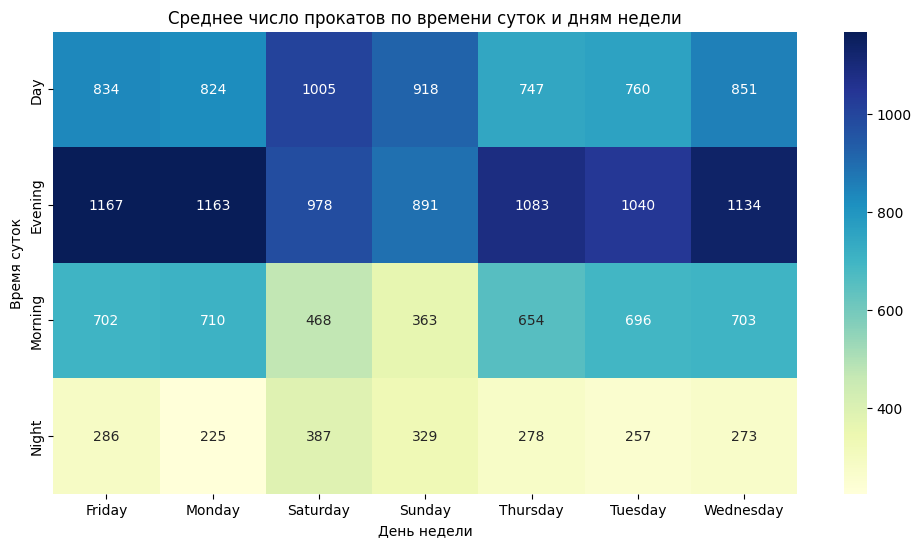

In [ ]:
def time_category(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Day'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'

merged_bike_data['Time_Category'] = merged_bike_data['Hour'].apply(time_category)

usage_by_time = merged_bike_data.groupby(['Time_Category', 'WeekDay'])['Rented Bike Count'].mean().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(usage_by_time, cmap='YlGnBu', annot=True, fmt=".0f")
plt.title('Среднее число прокатов по времени суток и дням недели')
plt.xlabel('День недели')
plt.ylabel('Время суток')
plt.show()

## Влияние погодных условий на прокаты

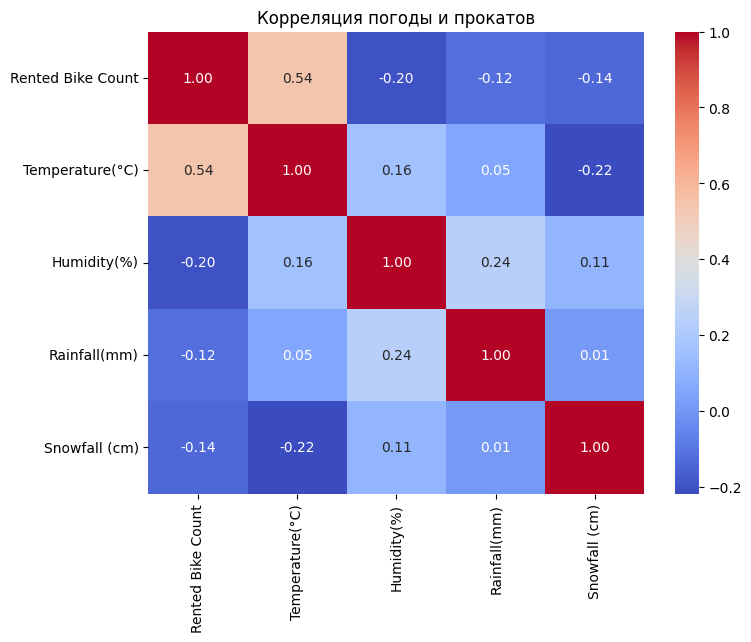

In [ ]:
weather_vars = ['Rented Bike Count', 'Temperature(°C)', 'Humidity(%)', 'Rainfall(mm)', 'Snowfall (cm)']
corr_matrix = merged_bike_data[weather_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляция погоды и прокатов")
plt.show()


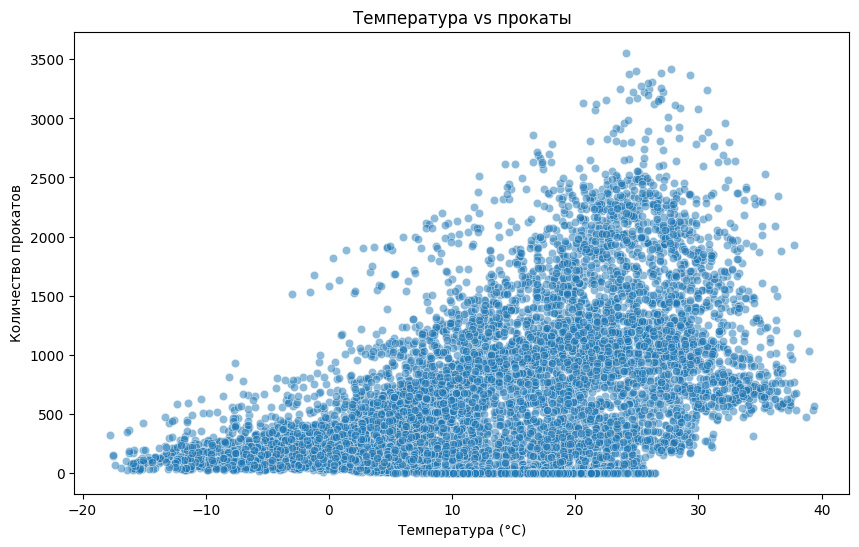

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_bike_data, x='Temperature(°C)', y='Rented Bike Count', alpha=0.5)
plt.title("Температура vs прокаты")
plt.xlabel("Температура (°C)")
plt.ylabel("Количество прокатов")
plt.show()

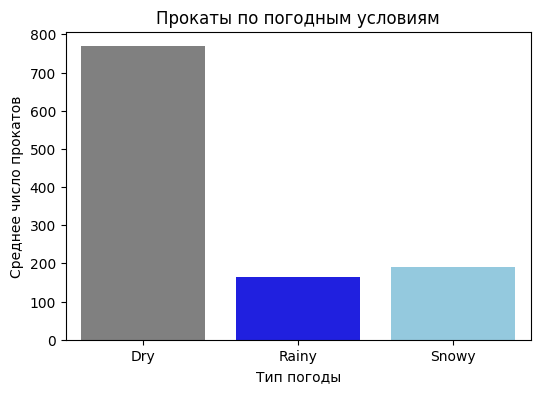

In [ ]:
merged_bike_data['Weather_Type'] = merged_bike_data.apply(
    lambda row: 'Rainy' if row['Rainfall(mm)'] > 0 else ('Snowy' if row['Snowfall (cm)'] > 0 else 'Dry'), axis=1
)

weather_avg = merged_bike_data.groupby('Weather_Type')['Rented Bike Count'].mean()

plt.figure(figsize=(6, 4))
sns.barplot(x=weather_avg.index, y=weather_avg.values, hue=weather_avg.index, palette=['gray', 'blue', 'skyblue'])
plt.ylabel("Среднее число прокатов")
plt.xlabel("Тип погоды")
plt.title("Прокаты по погодным условиям")
plt.show()

## Индекс комфортности и простое прогнозирование

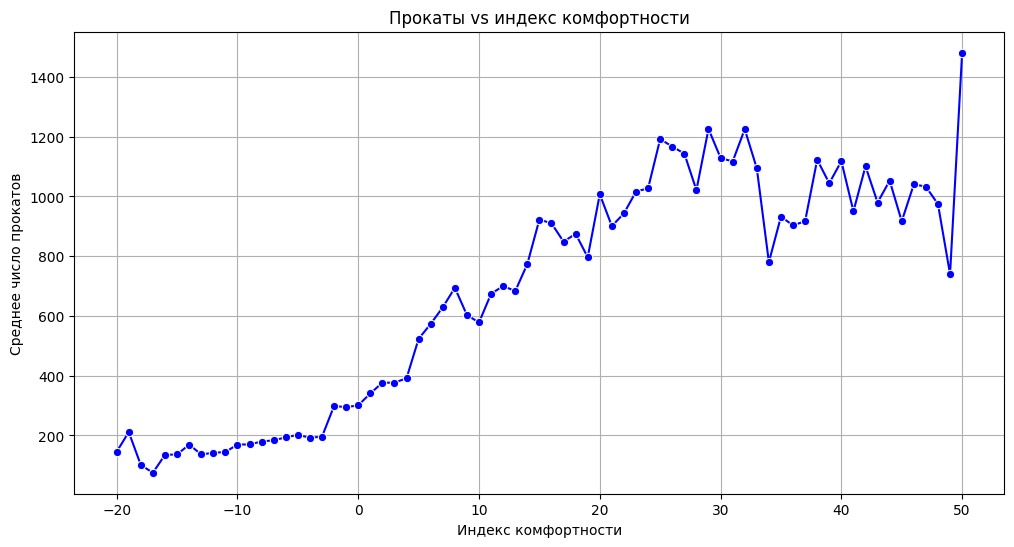

MAE простой модели: 430.83


In [ ]:
def windchill_index(temp, wind):
    return 13.12 + 0.6215 * temp - 11.37 * wind**0.16 + 0.3965 * temp * wind**0.16

def humidex_index(temp, dew):
    e = 6.11 * np.exp(5417.7530 * ((1 / 273.16) - (1 / (dew + 273.16))))
    h = (0.5555) * (e - 10)
    return temp + h

def comfort_score(row):
    if row['Temperature(°C)'] <= 2:
        return windchill_index(row['Temperature(°C)'], row['Wind speed (m/s)'])
    else:
        return humidex_index(row['Temperature(°C)'], row['Dew point temperature(°C)'])

merged_bike_data['Comfort_Score'] = merged_bike_data.apply(comfort_score, axis=1)
merged_bike_data['Comfort_Score_Rounded'] = merged_bike_data['Comfort_Score'].round()

comfort_avg = merged_bike_data.groupby('Comfort_Score_Rounded')['Rented Bike Count'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=comfort_avg.index, y=comfort_avg.values, marker="o", color="b")
plt.xlabel("Индекс комфортности")
plt.ylabel("Среднее число прокатов")
plt.title("Прокаты vs индекс комфортности")
plt.grid(True)
plt.show()


optimal_days = merged_bike_data[(merged_bike_data['Temperature(°C)'] > 15) & (merged_bike_data['Temperature(°C)'] < 30) & (merged_bike_data['Rainfall(mm)'] == 0)]
poor_days = merged_bike_data[(merged_bike_data['Temperature(°C)'] <= 15) | (merged_bike_data['Temperature(°C)'] >= 30) | (merged_bike_data['Rainfall(mm)'] > 0)]

optimal_avg = optimal_days['Rented Bike Count'].mean()
poor_avg = poor_days['Rented Bike Count'].mean()

merged_bike_data['Basic_Forecast'] = merged_bike_data.apply(
    lambda row: optimal_avg if (15 < row['Temperature(°C)'] < 30 and row['Rainfall(mm)'] == 0) else poor_avg, axis=1
)

mae_basic = np.mean(np.abs(merged_bike_data['Rented Bike Count'] - merged_bike_data['Basic_Forecast']))
print(f"MAE простой модели: {mae_basic:.2f}")

## Автоматизация: функции отчетов

<ipython-input-28-0e821db2f4b7>:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouped_data = df.resample('M', on='Date')['Rented Bike Count'].sum()



 Отчет за month:
Всего прокатов: 6172314.00
Среднее: 514359.50
Максимум: 896887.00
Минимум: 150006.00


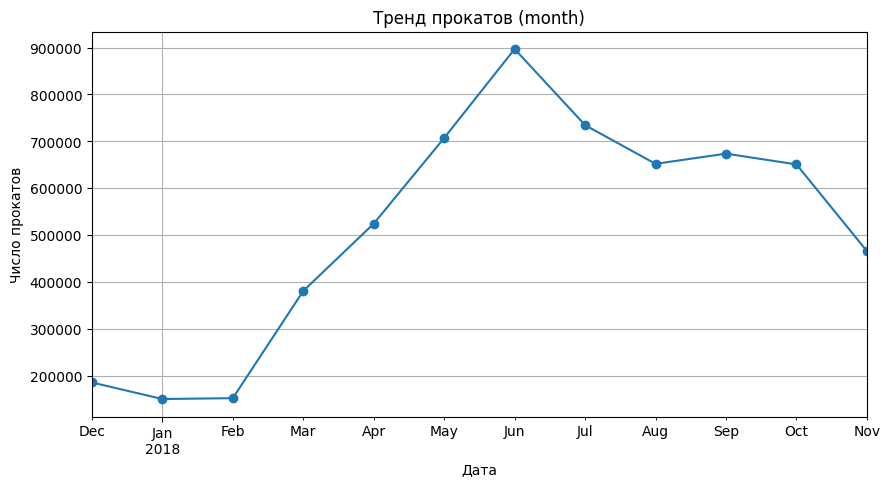


 Отчет за week:
Всего прокатов: 6172314.00
Среднее: 116458.75
Максимум: 225206.00
Минимум: 23203.00


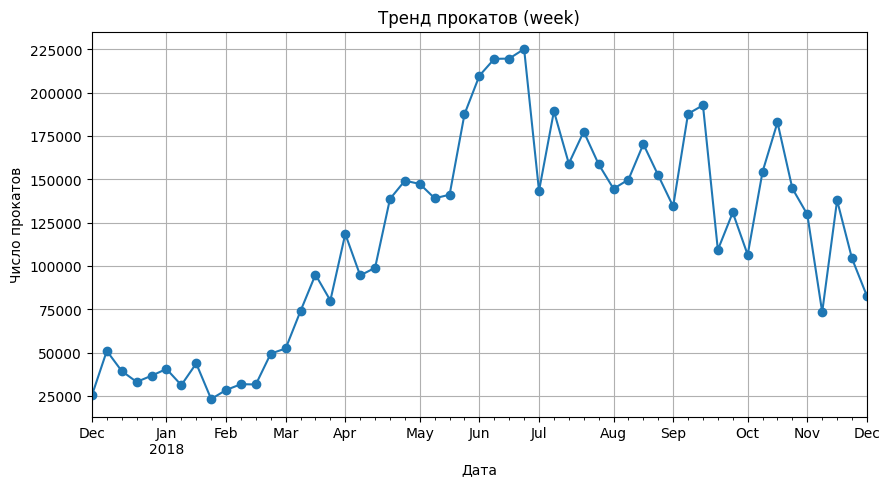

In [ ]:
def create_summary(df, timeframe='month'):
    if timeframe == 'day':
        grouped_data = df.groupby('Date')['Rented Bike Count'].sum()
    elif timeframe == 'week':
        grouped_data = df.resample('W', on='Date')['Rented Bike Count'].sum()
    elif timeframe == 'month':
        grouped_data = df.resample('M', on='Date')['Rented Bike Count'].sum()
    else:
        raise ValueError("Укажи 'day', 'week' или 'month'")

    stats = {
        'Всего прокатов': grouped_data.sum(),
        'Среднее': grouped_data.mean(),
        'Максимум': grouped_data.max(),
        'Минимум': grouped_data.min()
    }

    print(f"\n Отчет за {timeframe}:")
    for key, value in stats.items():
        print(f"{key}: {value:.2f}")

    plt.figure(figsize=(10, 5))
    grouped_data.plot(marker='o', linestyle='-')
    plt.xlabel("Дата")
    plt.ylabel("Число прокатов")
    plt.title(f"Тренд прокатов ({timeframe})")
    plt.grid()
    plt.show()

create_summary(merged_bike_data, 'month')
create_summary(merged_bike_data, 'week')

## Сводные таблицы и визуализация зависимостей"

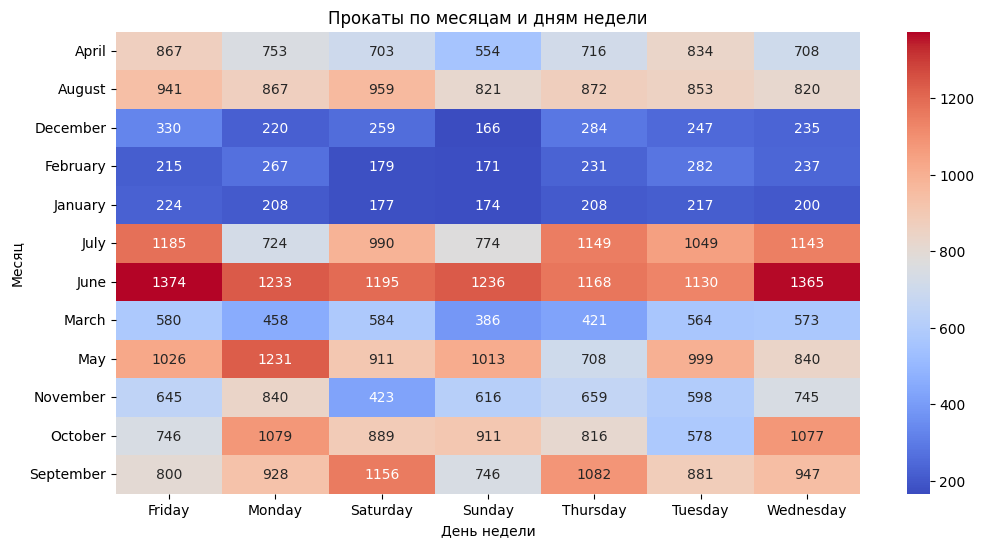

In [ ]:
merged_bike_data['Month'] = merged_bike_data['Date'].dt.month_name()


pivot_month_day = merged_bike_data.pivot_table(
    values='Rented Bike Count',
    index='Month',
    columns='WeekDay',
    aggfunc='mean'
)


plt.figure(figsize=(12, 6))
sns.heatmap(pivot_month_day, cmap='coolwarm', annot=True, fmt=".0f")
plt.title("Прокаты по месяцам и дням недели")
plt.xlabel("День недели")
plt.ylabel("Месяц")
plt.show()

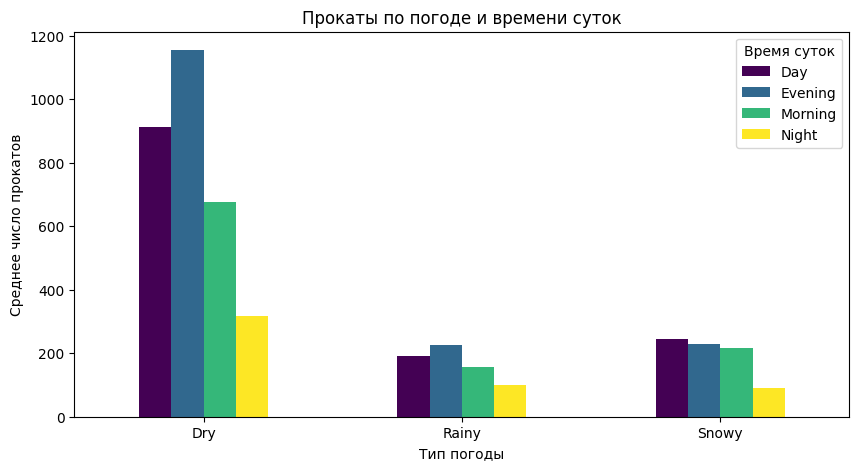

In [ ]:
pivot_weather_time = merged_bike_data.pivot_table(
    values='Rented Bike Count',
    index='Weather_Type',
    columns='Time_Category',
    aggfunc='mean'
)


pivot_weather_time.plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title("Прокаты по погоде и времени суток")
plt.xlabel("Тип погоды")
plt.ylabel("Среднее число прокатов")
plt.legend(title="Время суток")
plt.xticks(rotation=0)
plt.show()

## Интерактивный дашборд с Plotly

In [ ]:
daily_summary = merged_bike_data.groupby('Date')['Rented Bike Count'].sum().reset_index()
fig1 = px.line(daily_summary, x='Date', y='Rented Bike Count',
               title="📅 Динамика прокатов по дням",
               labels={'Rented Bike Count': 'Число прокатов', 'Date': 'Дата'},
               template='plotly_dark')
fig1.show()

# График зависимости от температуры
fig2 = px.scatter(merged_bike_data, x='Temperature(°C)', y='Rented Bike Count',
                  color='Seasons', title="🌡️ Прокаты vs температура",
                  labels={'Temperature(°C)': 'Температура (°C)', 'Rented Bike Count': 'Число прокатов'},
                  template='plotly_dark')
fig2.update_layout(xaxis=dict(rangeslider=dict(visible=True)))
fig2.show()

## Отчет с выводами

### Отчет по анализу прокатов велосипедов в Сеуле

#### Описание данных
Датасет содержит 8760 записей за 2018 год с почасовыми данными о прокатах велосипедов в Сеуле. Включает информацию о погоде (температура, осадки, влажность) и дополнительные признаки (праздники, дни недели).

#### Основные тенденции
Прокаты растут с весны до середины лета, резко падают в декабре. Лето и весна показывают высокий спрос благодаря погоде.

#### Сезонность
Будни имеют пики в 8 и 18 часов (поездки на работу), выходные — более равномерное распределение. Ночью спрос минимален.

#### Выбросы
Аномалии связаны с погодой (жара или дожди), а не с праздниками.

#### Влияние погоды
Температура — ключевой фактор (корреляция 0.5). Прокаты падают при осадках и экстремальных температурах (<0°C или >30°C).

#### Выводы
Спрос зависит от комфортности погоды. Оптимальные условия: 15-30°C без осадков.